In [15]:
from typing import List, TypedDict
from langgraph.graph import StateGraph
# StateGraph is a framework that help to design and manage the flow of tasks using graph structure.

In [16]:
class AgentState(TypedDict): 
    name: str
    age: str
    final_result: str
    skills: List[str]

In [17]:
def first_node(state:AgentState) -> AgentState:
    """This node will greet the user"""

    state["final_result"] = f"{state['name']} welcome to the system!"
    return state

def second_node(state:AgentState) -> AgentState:
    """This node will describe the user's age"""

    state["final_result"] = state["final_result"] + f" You are {state['age']} years old!"
    return state

def third_node(state:AgentState) -> AgentState:
    """This node will list the user's skills in a formatted string"""
    state["final_result"] = state["final_result"] + f" You have skills in: {', '.join(state['skills'])}"

    return state

In [18]:
graph = StateGraph(AgentState)

graph.add_node("personalize", first_node)
graph.add_node("age_description", second_node)
graph.add_node("skills_description", third_node)

graph.set_entry_point("personalize")
graph.add_edge("personalize", "age_description")
graph.add_edge("age_description", "skills_description")
graph.set_finish_point("skills_description")
app = graph.compile()

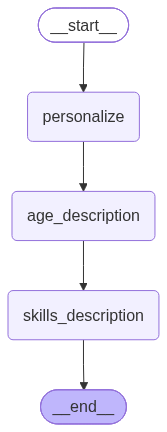

In [19]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [20]:
result = app.invoke({"name": "Linda", "age": 31, "skills":["Python", "Machine Learning", "LangGraph"]})

In [21]:
result['final_result']

'Linda welcome to the system! You are 31 years old! You have skills in: Python, Machine Learning, LangGraph'